[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_4_MultiModal.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

# LSDB: Building a Multi-Modal ML Training Dataset

In this notebook we'll learn how to:
- Cross-match two astronomical surveys across two data modalities: time-series (Gaia) and spectra (APOGEE)
- Preprocess heterogeneous nested data lazily with `map_rows`
- Truncate light curves to a fixed length of 15 epochs using `map_rows`
- Split a sky-partitioned catalog into train/val/test sets by HEALPix partition index
- Stream training batches with `InfiniteStream` and visualize both data modalities
- Export the result in three ML-ready formats: HATS (Parquet dataset), Lance, and PyTorch tensors

In [1]:
# # do you need to install the packages?
# # if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb s3fs huggingface_hub torch lancedb

In [2]:
import logging
import os
import warnings
from pathlib import Path

import pandas as pd

# Must be set before importing packages that use numexpr
os.environ["NUMEXPR_MAX_THREADS"] = "2"

import dask
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np
import pyarrow as pa
import torch
from dask.distributed import Client
from lsdb.streams import CatalogStream, InfiniteStream
from matplotlib import rcParams

%matplotlib inline
warnings.simplefilter("ignore")
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 550
rcParams["font.size"] = 20
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 2
dask.config.set({"dataframe.convert-string": False})

lsdb.show_versions()


--------      SYSTEM INFO      --------
python        : 3.13.13
python-bits   : 64
OS            : Darwin
OS-release    : 25.4.0
Version       : Darwin Kernel Version 25.4.0: Thu Mar 19 19:31:17 PDT 2026; root:xnu-12377.101.15~1/RELEASE_ARM64_T6020
machine       : arm64
processor     : arm
byteorder     : little
LC_ALL        : en_US.UTF-8
LANG          : en_US.UTF-8
--------   INSTALLED VERSIONS   --------
lsdb          : 0.9.2
hats          : 0.9.2
nested-pandas : 0.6.10
pandas        : 2.3.3
numpy         : 2.4.6
dask          : 2026.6.0
pyarrow       : 24.0.0
fsspec        : 2026.4.0


## Setup Dask Cluster

LSDB uses Dask for parallel, out-of-memory computation. We start a local cluster before loading any data.

In [3]:
client = Client(n_workers=1, memory_limit="10GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:8787/status


## The Two Surveys

We combine two catalogs to build a dataset where each object has measurements in both modalities:

| Survey | Modality | What we use |
|--------|----------|-------------|
| **Gaia DR3** | Time-series photometry | Light curves (G-band, first 15 epochs) |
| **APOGEE DR17** | Near-infrared spectroscopy | H-band flux spectrum |


In [4]:
LC_LENGTH = 15               # number of Gaia G-band epochs to keep per object

GAIA_PATH   = "https://data.lsdb.io/hats/gaia_dr3_epoch_phot"
APOGEE_PATH = "hf://datasets/hugging-science/mmu_apogee_dr17/"

## Load the Two Catalogs

Both catalogs are opened lazily: `open_catalog` reads only the HATS index metadata and partition layout, and no data is downloaded yet. Specifying `columns=` is important for performance; without it, every sub-field of the `epoch_photometry` struct (dozens of arrays in Gaia) would be fetched from every parquet file.

The `ra` and `dec` coordinate columns are always loaded automatically and do not need to be listed.

,source_id,ra,dec,epoch_photometry
npartitions=1305,,,,
"Order: 2, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],"nested<g_transit_time: [double], g_transit_mag..."
"Order: 2, Pixel: 1",...,...,...,...
...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...


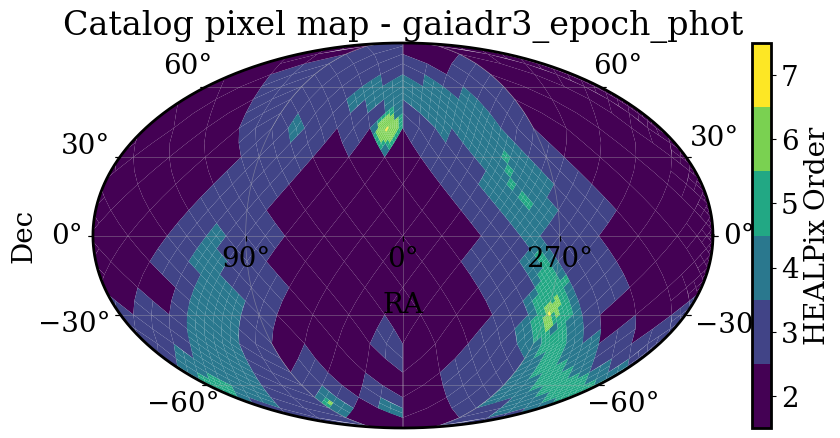

In [5]:
gaia = lsdb.open_catalog(
    GAIA_PATH,
    columns=["source_id",
             "epoch_photometry.g_transit_time", "epoch_photometry.g_transit_mag",
             "epoch_photometry.g_transit_flux_over_error", "epoch_photometry.variability_flag_g_reject"],
    # Pre-filter for objects with enough epochs (Gaia has no per-band filter id; G-band is chosen by column)
    filters=[("n_transits", ">=", LC_LENGTH)],
)
# Keep only clean epochs and objects with enough measurements
gaia = gaia.query("not epoch_photometry.variability_flag_g_reject")
gaia = gaia.query(f"epoch_photometry.len() >= {LC_LENGTH}")
gaia.plot_pixels()
gaia

,ra,dec,spectrum
npartitions=1820,,,
"Order: 4, Pixel: 0",double[pyarrow],double[pyarrow],"nested<lambda: [float], flux: [float], mask: [..."
"Order: 7, Pixel: 234",...,...,...
...,...,...,...
"Order: 4, Pixel: 3070",...,...,...
"Order: 4, Pixel: 3071",...,...,...


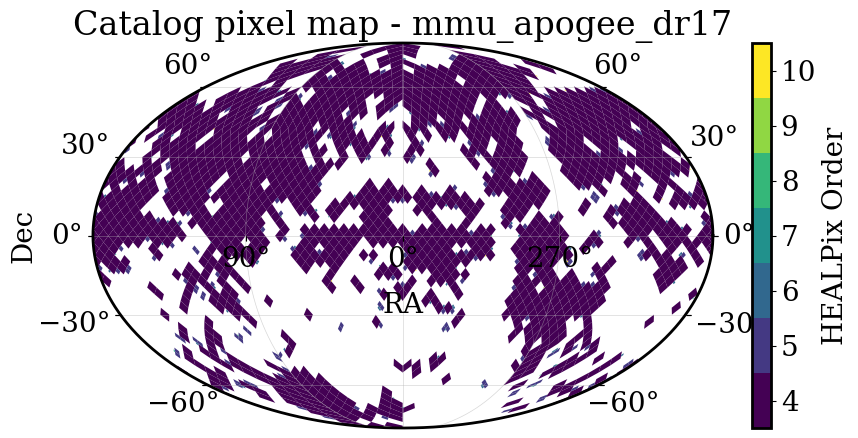

In [6]:
apogee = lsdb.open_catalog(
    APOGEE_PATH,
    columns=["spectrum.lambda", "spectrum.flux", "spectrum.mask"],
    filters=[("teff", ">", 3000), ("teff", "<", 8000)],
)
apogee.plot_pixels()
apogee

## Cross-Match the Two Catalogs

We cross-match APOGEE onto Gaia, keeping Gaia as the left anchor.
The cross-match reduces the object count to those with coverage in both surveys; you can swap the order and use `how=left` to keep no-matches from the "left" catalog.

With `suffix_method="overlapping_columns"`, only columns present in **both** catalogs get a suffix (e.g. `ra` and `dec`). Using `""` as the left suffix means the anchor catalog's coordinates keep their names, while right-side duplicates receive the right suffix.

+--------+----------------+------------------------+
| Column | Left (suffix=) | Right (suffix=_apogee) |
+--------+----------------+------------------------+
|  dec   |      dec       |       dec_apogee       |
|   ra   |       ra       |       ra_apogee        |
+--------+----------------+------------------------+


,source_id,ra,dec,epoch_photometry,ra_apogee,dec_apogee,spectrum,_dist_arcsec
npartitions=2082,,,,,,,,
"Order: 4, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],"nested<g_transit_time: [double], g_transit_mag...",double[pyarrow],double[pyarrow],"nested<lambda: [float], flux: [float], mask: [...",double[pyarrow]
"Order: 7, Pixel: 234",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3070",...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3071",...,...,...,...,...,...,...,...


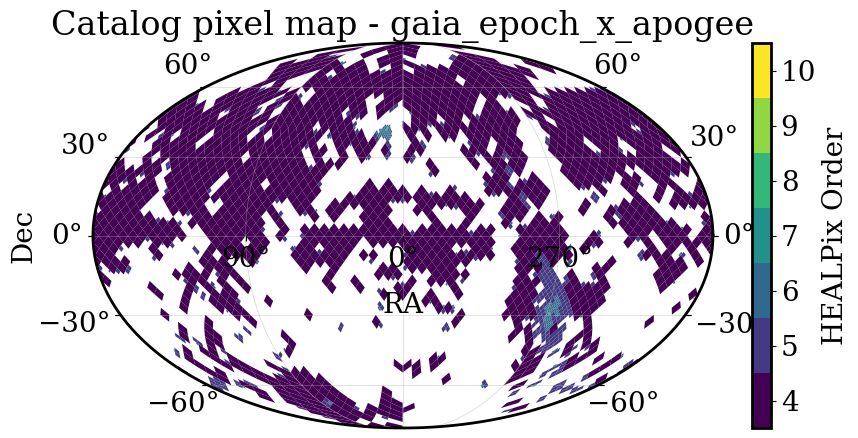

In [7]:
result_catalog = gaia.crossmatch(
    apogee,
    radius_arcsec=1.0,
    suffixes=("", "_apogee"),
    suffix_method="overlapping_columns",
    output_catalog_name="gaia_epoch_x_apogee",
)
result_catalog.plot_pixels()
result_catalog

## Lazy Preprocessing

We preprocess each modality lazily so the transformations execute partition-by-partition
at compute time rather than loading the full dataset into memory:

1. Gaia G-band light curve: keep the first 15 epochs, derive the magnitude error from `g_transit_flux_over_error`, and shift the time to a compact float32; store result in a new nested column `lc_start`
2. APOGEE spectrum: interpolate to a fixed-length wavelength grid and respect the bad-pixel mask; store result in `inter_spec`

Both transformations use `map_rows`, the idiomatic nested-pandas primitive for per-object functions that read nested sub-columns and write new ones.

In [8]:
MAG_ERR_FACTOR = 2.5 / np.log(10)  # convert flux signal-to-noise to magnitude error
TIME_OFFSET = 1700                 # Gaia BJD offset for compact float32 times


def truncate_lc(time, mag, flux_over_error):
    """Keep the first LC_LENGTH epochs and convert to float32."""
    return {
        "lc_start.time":   (time[:LC_LENGTH] - TIME_OFFSET).astype(np.float32),
        "lc_start.mag":    mag[:LC_LENGTH].astype(np.float32),
        "lc_start.magerr": (MAG_ERR_FACTOR / flux_over_error[:LC_LENGTH]).astype(np.float32),
    }


def truncate_lc_partition(partition):
    if len(partition) == 0:
        return partition.assign(
            lc_start=pd.Series([], dtype=npd.NestedDtype({
                "time":   pa.float32(),
                "mag":    pa.float32(),
                "magerr": pa.float32(),
            }))
        ).drop(columns=["epoch_photometry"])
    return partition.map_rows(
        truncate_lc,
        columns=["epoch_photometry.g_transit_time", "epoch_photometry.g_transit_mag",
                 "epoch_photometry.g_transit_flux_over_error"],
        row_container="args",
        append_columns=True,
    ).drop(columns=["epoch_photometry"])


result_catalog = result_catalog.map_partitions(truncate_lc_partition)

In [9]:
N_WAVE = 500
FIXED_WAVE = np.linspace(15153, 16943, N_WAVE, dtype=np.float32)


def interpolate_spectrum(wave, flux, mask):
    good = np.isfinite(flux) & (mask == 0)
    interp = np.interp(FIXED_WAVE, wave[good], flux[good], left=0, right=0).astype(np.float32)
    return {"valid": np.any(interp > 0), "inter_spec.flux": interp}


def interpolate_spectrum_partition(partition):
    if len(partition) == 0:
        return partition.assign(
            valid=pd.Series([], dtype=bool),
            inter_spec=pd.Series([], dtype=npd.NestedDtype({"flux": pa.float32()})),
        ).drop(columns=["spectrum"])
    result = partition.map_rows(
        interpolate_spectrum,
        columns=["spectrum.lambda", "spectrum.flux", "spectrum.mask"],
        row_container="args",
        append_columns=True,
    )
    return result.drop(columns=["spectrum"])

result_catalog = result_catalog.map_partitions(interpolate_spectrum_partition)
result_catalog = result_catalog.query("valid").drop(columns=["valid"])
result_catalog

,source_id,ra,dec,ra_apogee,dec_apogee,_dist_arcsec,lc_start,inter_spec
npartitions=2082,,,,,,,,
"Order: 4, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<time: [float], mag: [float], magerr: [f...",nested<flux: [float]>
"Order: 7, Pixel: 234",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3070",...,...,...,...,...,...,...,...
"Order: 4, Pixel: 3071",...,...,...,...,...,...,...,...


## Train / Validation / Test Split by Partitions

For sky-partitioned catalogs the natural split unit is the HEALPix partition rather than the
individual object. Splitting by partition prevents spatial leakage, since nearby objects that share a
tile always land in the same split. LSDB supports partition slicing with `catalog.partitions[start:end]`.

In [10]:
n = result_catalog.npartitions
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_catalog = result_catalog.partitions[:n_train]
val_catalog   = result_catalog.partitions[n_train : n_train + n_val]
test_catalog  = result_catalog.partitions[n_train + n_val :]

print(f"Total partitions : {n}")
print(f"Train            : {train_catalog.npartitions}")
print(f"Validation       : {val_catalog.npartitions}")
print(f"Test             : {test_catalog.npartitions}")

Total partitions : 2082
Train            : 1457
Validation       : 312
Test             : 313


## Training Loop with `InfiniteStream`

`InfiniteStream` draws random partition subsets from the catalog endlessly (with a fixed `seed` for
reproducibility). Here we plot one example object from the first batch to show what multi-modal
training data looks like at runtime.

The `break` at the bottom is intentional; remove it and replace the plotting block with
your own `model.train_step(chunk)` to run the real training loop.

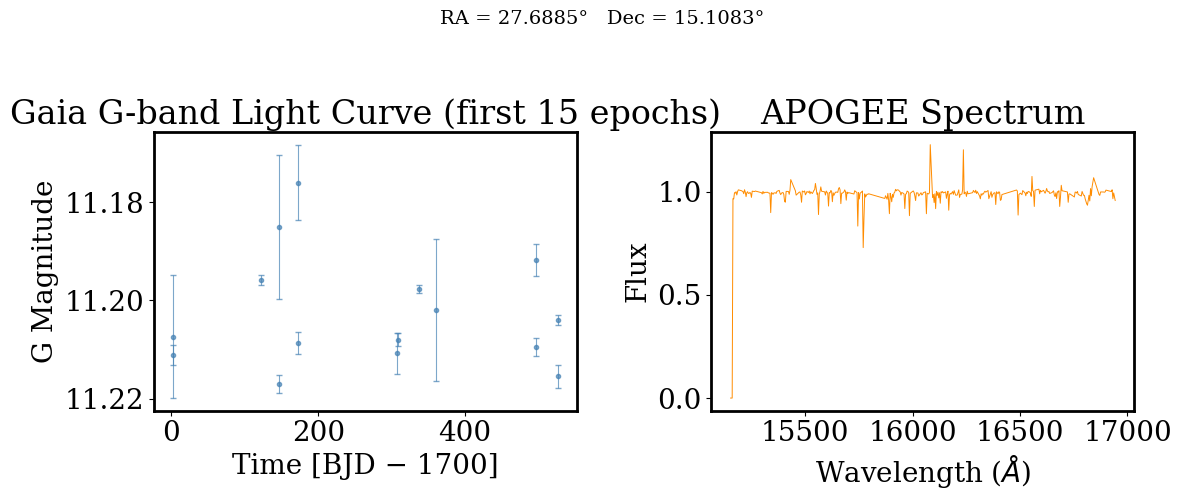

In [11]:
# Increase partitions_per_chunk to Dask Client's n_workers or larger
stream = InfiniteStream(train_catalog, partitions_per_chunk=1, seed=42)

for chunk in stream:
    if len(chunk) == 0:
        print(f"Empty chunk")
        continue

    row = chunk.iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: Gaia G-band light curve (first LC_LENGTH epochs)
    lc = row["lc_start"]
    axes[0].errorbar(
        lc["time"], lc["mag"], yerr=lc["magerr"],
        fmt="o", ms=3, alpha=0.7, elinewidth=0.8, capsize=2, color="steelblue",
    )
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Time [BJD − 1700]")
    axes[0].set_ylabel("G Magnitude")
    axes[0].set_title(f"Gaia G-band Light Curve (first {LC_LENGTH} epochs)")

    # Panel 2: APOGEE spectrum (interpolated to fixed grid)
    axes[1].plot(FIXED_WAVE, row["inter_spec"]["flux"], lw=0.7, color="darkorange")
    axes[1].set_xlabel(r"Wavelength ($\AA$)")
    axes[1].set_ylabel("Flux")
    axes[1].set_title("APOGEE Spectrum")

    plt.suptitle(
        f"RA = {row['ra']:.4f}°   Dec = {row['dec']:.4f}°",
        y=1.02, fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    # ↑ Replace the plotting block above with your training step:
    # loss = model.train_step(chunk)
    break  # Remove this line to run the full training loop

Validation and test sets use `CatalogStream` (finite, single-pass) so each held-out object is
evaluated exactly once:

```python
val_stream = CatalogStream(val_catalog, partitions_per_chunk=1)
for chunk in val_stream:
    metrics = model.eval_step(chunk)
```

## Save to HATS

`write_catalog` triggers the full lazy pipeline: pre-filtering, file reading,
cross-matching, and writing each partition to disk as it finishes. You can re-open this catalog
with `lsdb.open_catalog` later or use any parquet-dataset compatible reader, e.g.
Pandas, Dask, Polars, etc.

Here and below we select the first 10 partitions only for demonstration purposes: remove `.partitions[:10]` to run with the full catalog.

In [12]:
%%time
result_catalog.partitions[:10].write_catalog("hats/multimodal_variable_stars/")

CPU times: user 1.2 s, sys: 236 ms, total: 1.43 s
Wall time: 29.1 s


## Save to Lance

[Lance](https://lancedb.github.io/lance/) is a columnar format optimised for random-access ML
workflows.

In [13]:
%%time
result_catalog.partitions[:10].to_lance("lance/multimodal_variable_stars/")

Writing to Lance: 100%|██████████| 10/10 [02:26<00:00, 14.63s/it]

Optimizing Lance dataset...
Finished writing output to lance. Path: lance/multimodal_variable_stars, Table name: data
CPU times: user 6.22 s, sys: 1.42 s, total: 7.65 s
Wall time: 2min 27s


## Save to PyTorch Tensors

We use `map_partitions` to write one `.pt` file per HEALPix partition. Each file is a dict of tensors saved with `torch.save`.

Because `lc_start` has exactly `LC_LENGTH` epochs per object, we can unpack its nested sub-columns into 2D tensors with a single `.reshape()`, with no padding or masking needed:

```python
lc_time = np.array(df["lc_start.time"], dtype=np.float32).reshape(len(df), LC_LENGTH)
```

Both modalities end up as `(n_objects, n_features)` tensors, ready for batching.

In [14]:
def save_torch_partition(df, healpix, *, output_dir):
    """Write one .pt file per partition as a dict of tensors.

    Returns a summary DataFrame so map_partitions can collect statistics.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if len(df) == 0:
        return pd.DataFrame({"n_objects": [0], "n_bytes": [0]})

    fname = output_dir / f"order{healpix.order}_pixel{healpix.pixel}.pt"

    # Fixed-length light curves: unpack nested sub-columns into (n_objects, LC_LENGTH) tensors
    lc_time   = np.array(df["lc_start.time"], dtype=np.float32).reshape(len(df), LC_LENGTH)
    lc_mag    = np.array(df["lc_start.mag"], dtype=np.float32).reshape(len(df), LC_LENGTH)
    lc_magerr = np.array(df["lc_start.magerr"], dtype=np.float32).reshape(len(df), LC_LENGTH)

    # Fixed-length spectrum: unpack into (n_objects, N_WAVE)
    spec_flux = np.array(df["inter_spec.flux"], dtype=np.float32).reshape(len(df), N_WAVE)

    data = {
        "lc_time":      torch.from_numpy(lc_time),    # (n_objects, LC_LENGTH)
        "lc_mag":       torch.from_numpy(lc_mag),
        "lc_magerr":    torch.from_numpy(lc_magerr),
        "spectrum_flux": torch.from_numpy(spec_flux), # (n_objects, N_WAVE)
    }
    torch.save(data, fname)

    return pd.DataFrame({"n_objects": [len(df)], "n_bytes": [fname.stat().st_size]})

In [15]:
%%time
stats = result_catalog.partitions[:10].map_partitions(
    save_torch_partition,
    output_dir="torch/multimodal_variable_stars",
    include_pixel=True,
).compute()

print(stats)
print(f"\nTotal objects : {stats['n_objects'].sum():,}")
print(f"Total size    : {stats['n_bytes'].sum() / (1 << 20):.1f} MB")

   n_objects  n_bytes
0          1     4633
0          0        0
0          6    15385
0          5    13209
0          1     4653
0          3     8793
0          3     8793
0          4    11043
0          2     6627
0         17    39523

Total objects : 42
Total size    : 0.1 MB
CPU times: user 3.87 s, sys: 627 ms, total: 4.5 s
Wall time: 1min 13s


In [16]:
client.close()